# 🛡️ AI Cyber Threat Detection

## Initial Exploratory Data Analysis

**Dataset:** CIC-IDS2017  
**Project:** AI Cyber Threat Detection  
**Phase:** Day 2 — Data Understanding & EDA

### Objectives

- Understand the cybersecurity dataset
- Inspect network traffic features
- Identify normal and malicious traffic
- Check data types and missing values
- Analyze class distribution
- Detect duplicate records
- Identify potential data-quality problems
- Prepare the dataset for Machine Learning

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
DATA_PATH = "../data/raw/MachineLearningCSV"

csv_files = glob.glob(os.path.join(DATA_PATH, "*.csv"))

print(f"Number of CSV files found: {len(csv_files)}")

for file in csv_files:
    size_mb = os.path.getsize(file) / (1024 ** 2)
    print(f"{os.path.basename(file):60} {size_mb:,.2f} MB")

Number of CSV files found: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv             73.55 MB
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         73.34 MB
Friday-WorkingHours-Morning.pcap_ISCX.csv                    55.62 MB
Monday-WorkingHours.pcap_ISCX.csv                            168.73 MB
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  79.25 MB
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv       49.61 MB
Tuesday-WorkingHours.pcap_ISCX.csv                           128.82 MB
Wednesday-workingHours.pcap_ISCX.csv                         214.74 MB


In [4]:
sample_file = csv_files[0]

print("Inspecting file:")
print(os.path.basename(sample_file))

sample_df = pd.read_csv(sample_file, nrows=5000)

print("\nSample shape:")
print(sample_df.shape)

sample_df.head()

Inspecting file:
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Sample shape:
(5000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
print("Number of columns:", len(sample_df.columns))

print("\nColumns:")
for i, column in enumerate(sample_df.columns, start=1):
    print(f"{i:2}. {column}")

Number of columns: 79

Columns:
 1.  Destination Port
 2.  Flow Duration
 3.  Total Fwd Packets
 4.  Total Backward Packets
 5. Total Length of Fwd Packets
 6.  Total Length of Bwd Packets
 7.  Fwd Packet Length Max
 8.  Fwd Packet Length Min
 9.  Fwd Packet Length Mean
10.  Fwd Packet Length Std
11. Bwd Packet Length Max
12.  Bwd Packet Length Min
13.  Bwd Packet Length Mean
14.  Bwd Packet Length Std
15. Flow Bytes/s
16.  Flow Packets/s
17.  Flow IAT Mean
18.  Flow IAT Std
19.  Flow IAT Max
20.  Flow IAT Min
21. Fwd IAT Total
22.  Fwd IAT Mean
23.  Fwd IAT Std
24.  Fwd IAT Max
25.  Fwd IAT Min
26. Bwd IAT Total
27.  Bwd IAT Mean
28.  Bwd IAT Std
29.  Bwd IAT Max
30.  Bwd IAT Min
31. Fwd PSH Flags
32.  Bwd PSH Flags
33.  Fwd URG Flags
34.  Bwd URG Flags
35.  Fwd Header Length
36.  Bwd Header Length
37. Fwd Packets/s
38.  Bwd Packets/s
39.  Min Packet Length
40.  Max Packet Length
41.  Packet Length Mean
42.  Packet Length Std
43.  Packet Length Variance
44. FIN Flag Count
45.  SYN Fla

In [6]:
sample_df.columns = (
sample_df.columns.str.strip()
.str.replace(" ", "_")
)

print(sample_df.columns.tolist())

['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Bwd_PSH_Flags', 'Fwd_URG_Flags', 'Bwd_URG_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_Flag_Count', 'CWE_Flag_Count', 'ECE_Flag_Count

In [7]:
sample_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 79 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination_Port             5000 non-null   int64  
 1   Flow_Duration                5000 non-null   int64  
 2   Total_Fwd_Packets            5000 non-null   int64  
 3   Total_Backward_Packets       5000 non-null   int64  
 4   Total_Length_of_Fwd_Packets  5000 non-null   int64  
 5   Total_Length_of_Bwd_Packets  5000 non-null   int64  
 6   Fwd_Packet_Length_Max        5000 non-null   int64  
 7   Fwd_Packet_Length_Min        5000 non-null   int64  
 8   Fwd_Packet_Length_Mean       5000 non-null   float64
 9   Fwd_Packet_Length_Std        5000 non-null   float64
 10  Bwd_Packet_Length_Max        5000 non-null   int64  
 11  Bwd_Packet_Length_Min        5000 non-null   int64  
 12  Bwd_Packet_Length_Mean       5000 non-null   float64
 13  Bwd_Packet_Length_Std        

In [8]:
sample_df.describe(include="all").T

c:\Documents\Projects\Tendayproject\cyber_threat_detection\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Documents\Projects\Tendayproject\cyber_threat_detection\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Destination_Port,5000.0,NaN,NaN,NaN,6628.9114,16932.230339,0.0,53.0,80.0,443.0,60966.0
Flow_Duration,5000.0,NaN,NaN,NaN,11066878.115,29623412.962942,0.0,240.75,49303.5,502783.0,119994697.0
Total_Fwd_Packets,5000.0,NaN,NaN,NaN,8.4064,27.655969,1.0,2.0,2.0,7.0,1611.0
Total_Backward_Packets,5000.0,NaN,NaN,NaN,8.8696,34.63749,0.0,1.0,2.0,5.0,1935.0
Total_Length_of_Fwd_Packets,5000.0,NaN,NaN,NaN,980.414,6562.207128,0.0,43.0,76.0,388.25,118736.0
Total_Length_of_Bwd_Packets,5000.0,NaN,NaN,NaN,10450.2026,60837.112085,0.0,6.0,168.0,693.25,3433707.0
Fwd_Packet_Length_Max,5000.0,NaN,NaN,NaN,236.1648,612.834729,0.0,30.0,44.0,197.0,11680.0
Fwd_Packet_Length_Min,5000.0,NaN,NaN,NaN,20.3086,22.739375,0.0,0.0,6.0,41.0,247.0
Fwd_Packet_Length_Mean,5000.0,NaN,NaN,NaN,61.322099,166.606407,0.0,18.5,37.0,50.5125,2258.88
Fwd_Packet_Length_Std,5000.0,NaN,NaN,NaN,67.067721,193.178088,0.0,0.0,0.0,71.172809,2650.906236


In [9]:
label_columns = [
    column for column in sample_df.columns
    if "label" in column.lower()
]

LABEL_COLUMN = label_columns[0]

print("Target column:", LABEL_COLUMN)

Target column: Label


In [10]:
sample_df[LABEL_COLUMN].value_counts()

Label
BENIGN    5000
Name: count, dtype: int64

In [11]:
for file in csv_files:
    print("\n" + "=" * 80)
    print(os.path.basename(file))

    # Read only the header
    header_df = pd.read_csv(file, nrows=0)

    # Clean column names
    cleaned_columns = (
        header_df.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    # Find the original Label column
    label_index = [
        i for i, column in enumerate(cleaned_columns)
        if column.lower() == "label"
    ]

    if not label_index:
        print("⚠️ Label column not found!")
        continue

    # Get the original column name from the CSV
    original_label_column = header_df.columns[label_index[0]]

    # Read only the actual label column
    temp_df = pd.read_csv(
        file,
        usecols=[original_label_column]
    )

    # Clean the label values
    temp_df[original_label_column] = (
        temp_df[original_label_column]
        .astype(str)
        .str.strip()
    )

    print(temp_df[original_label_column].value_counts())


Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64

Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 Label
PortScan    158930
BENIGN      127537
Name: count, dtype: int64

Friday-WorkingHours-Morning.pcap_ISCX.csv
 Label
BENIGN    189067
Bot         1966
Name: count, dtype: int64

Monday-WorkingHours.pcap_ISCX.csv
 Label
BENIGN    529918
Name: count, dtype: int64

Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 Label
BENIGN          288566
Infiltration        36
Name: count, dtype: int64

Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 Label
BENIGN                        168186
Web Attack � Brute Force        1507
Web Attack � XSS                 652
Web Attack � Sql Injection        21
Name: count, dtype: int64

Tuesday-WorkingHours.pcap_ISCX.csv
 Label
BENIGN         432074
FTP-Patator      7938
SSH-Patator      5897
Name: count, dtype: int64

Wednesday-workingHours.pcap_ISCX.csv
 Label
BENIGN

In [12]:
label_summary = []

for file in csv_files:
    print(f"Processing: {os.path.basename(file)}")

    header_df = pd.read_csv(file, nrows=0)

    # Find the label column
    cleaned_columns = (
        header_df.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    label_index = [
        i for i, column in enumerate(cleaned_columns)
        if column.lower() == "label"
    ]

    if not label_index:
        print("⚠️ Label column not found")
        continue

    original_label_column = header_df.columns[label_index[0]]

    # Read only labels
    labels = pd.read_csv(
        file,
        usecols=[original_label_column]
    )[original_label_column]

    labels = labels.astype(str).str.strip()

    counts = labels.value_counts()

    for label, count in counts.items():
        label_summary.append({
            "File": os.path.basename(file),
            "Label": label,
            "Count": count
        })

label_summary_df = pd.DataFrame(label_summary)

label_summary_df

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Processing: Monday-WorkingHours.pcap_ISCX.csv
Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Processing: Wednesday-workingHours.pcap_ISCX.csv


,File,Label,Count
0,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,DDoS,128027
1,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,BENIGN,97718
2,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,PortScan,158930
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,BENIGN,127537
4,Friday-WorkingHours-Morning.pcap_ISCX.csv,BENIGN,189067
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,Bot,1966
6,Monday-WorkingHours.pcap_ISCX.csv,BENIGN,529918
7,Thursday-WorkingHours-Afternoon-Infilteration....,BENIGN,288566
8,Thursday-WorkingHours-Afternoon-Infilteration....,Infiltration,36
9,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,BENIGN,168186


In [13]:
overall_label_counts = (
    label_summary_df
    .groupby("Label")["Count"]
    .sum()
    .sort_values(ascending=False)
)

overall_label_counts

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: Count, dtype: int64

In [14]:
overall_percentages = (
    overall_label_counts
    / overall_label_counts.sum()
    * 100
).round(2)

overall_percentages

Label
BENIGN                        80.30
DoS Hulk                       8.16
PortScan                       5.61
DDoS                           4.52
DoS GoldenEye                  0.36
FTP-Patator                    0.28
SSH-Patator                    0.21
DoS slowloris                  0.20
DoS Slowhttptest               0.19
Bot                            0.07
Web Attack � Brute Force       0.05
Web Attack � XSS               0.02
Infiltration                   0.00
Web Attack � Sql Injection     0.00
Heartbleed                     0.00
Name: Count, dtype: float64

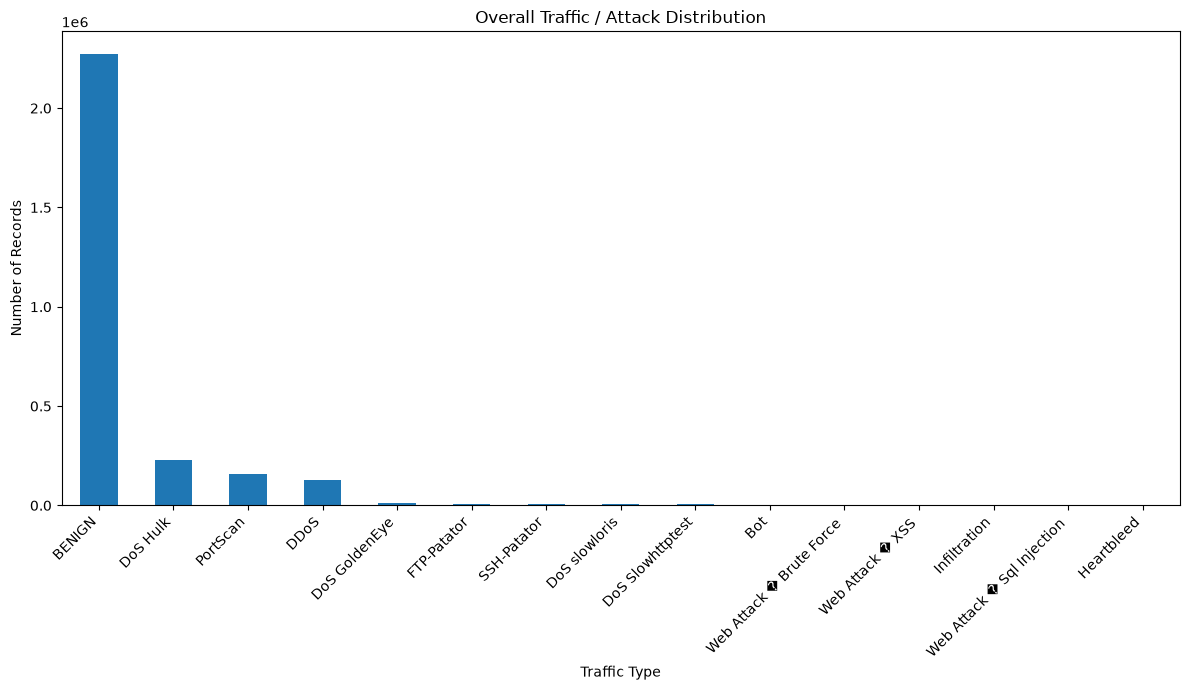

In [15]:
plt.figure(figsize=(12, 7))

overall_label_counts.plot(kind="bar")

plt.title("Overall Traffic / Attack Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [16]:
total_records = overall_label_counts.sum()

print("Total records:", total_records)

overall_percentages = (
    overall_label_counts
    / total_records
    * 100
).round(4)

print("\nPercentage distribution:")
print(overall_percentages)

Total records: 2830743

Percentage distribution:
Label
BENIGN                        80.3004
DoS Hulk                       8.1630
PortScan                       5.6144
DDoS                           4.5227
DoS GoldenEye                  0.3636
FTP-Patator                    0.2804
SSH-Patator                    0.2083
DoS slowloris                  0.2048
DoS Slowhttptest               0.1943
Bot                            0.0695
Web Attack � Brute Force       0.0532
Web Attack � XSS               0.0230
Infiltration                   0.0013
Web Attack � Sql Injection     0.0007
Heartbleed                     0.0004
Name: Count, dtype: float64


In [17]:
attack_count = overall_label_counts.drop("BENIGN").sum()
benign_count = overall_label_counts["BENIGN"]

binary_distribution = pd.Series({
    "BENIGN": benign_count,
    "ATTACK": attack_count
})

print("Binary distribution:")
print(binary_distribution)

print("\nBinary percentages:")
print(
    (binary_distribution / binary_distribution.sum() * 100)
    .round(2)
)

Binary distribution:
BENIGN    2273097
ATTACK     557646
dtype: int64

Binary percentages:
BENIGN    80.3
ATTACK    19.7
dtype: float64


In [18]:
missing_counts = {}

for file in csv_files:
    print(f"Checking: {os.path.basename(file)}")

    for chunk in pd.read_csv(file, chunksize=100000):
        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.replace(" ", "_")
        )

        chunk_missing = chunk.isnull().sum()

        for column, count in chunk_missing.items():
            missing_counts[column] = (
                missing_counts.get(column, 0) + count
            )

missing_series = (
    pd.Series(missing_counts)
    .sort_values(ascending=False)
)

print("\nColumns containing missing values:")
print(missing_series[missing_series > 0])

Checking: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Checking: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Checking: Friday-WorkingHours-Morning.pcap_ISCX.csv
Checking: Monday-WorkingHours.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Checking: Tuesday-WorkingHours.pcap_ISCX.csv
Checking: Wednesday-workingHours.pcap_ISCX.csv

Columns containing missing values:
Flow_Bytes/s    1358
dtype: int64


In [19]:
infinite_counts = {}

for file in csv_files:
    print(f"Checking: {os.path.basename(file)}")

    for chunk in pd.read_csv(file, chunksize=100000):
        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.replace(" ", "_")
        )

        numeric_cols = chunk.select_dtypes(
            include=np.number
        ).columns

        inf_counts = np.isinf(
            chunk[numeric_cols]
        ).sum()

        for column, count in inf_counts.items():
            infinite_counts[column] = (
                infinite_counts.get(column, 0) + count
            )

infinite_series = (
    pd.Series(infinite_counts)
    .sort_values(ascending=False)
)

print("\nColumns containing infinite values:")
print(infinite_series[infinite_series > 0])

Checking: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Checking: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Checking: Friday-WorkingHours-Morning.pcap_ISCX.csv
Checking: Monday-WorkingHours.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Checking: Tuesday-WorkingHours.pcap_ISCX.csv
Checking: Wednesday-workingHours.pcap_ISCX.csv

Columns containing infinite values:
Flow_Packets/s    2867
Flow_Bytes/s      1509
dtype: int64


In [20]:
duplicate_sample = sample_df.duplicated().sum()

print("Duplicate rows in our 5,000-row sample:", duplicate_sample)

print(
    f"Duplicate percentage: "
    f"{duplicate_sample / len(sample_df) * 100:.2f}%"
)



Duplicate rows in our 5,000-row sample: 26
Duplicate percentage: 0.52%


In [21]:
print(label_summary_df["Label"].unique())

<StringArray>
[                      'DDoS',                     'BENIGN',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack � Brute Force',
           'Web Attack � XSS', 'Web Attack � Sql Injection',
                'FTP-Patator',                'SSH-Patator',
                   'DoS Hulk',              'DoS GoldenEye',
              'DoS slowloris',           'DoS Slowhttptest',
                 'Heartbleed']
Length: 15, dtype: str


In [22]:
label_mapping = {
    "Web Attack � Brute Force": "Web Attack - Brute Force",
    "Web Attack � XSS": "Web Attack - XSS",
    "Web Attack � Sql Injection": "Web Attack - SQL Injection"
}

label_summary_df["Label_Clean"] = (
    label_summary_df["Label"]
    .replace(label_mapping)
)

label_summary_df[["Label", "Label_Clean"]].drop_duplicates()

,Label,Label_Clean
0,DDoS,DDoS
1,BENIGN,BENIGN
2,PortScan,PortScan
5,Bot,Bot
8,Infiltration,Infiltration
10,Web Attack � Brute Force,Web Attack - Brute Force
11,Web Attack � XSS,Web Attack - XSS
12,Web Attack � Sql Injection,Web Attack - SQL Injection
14,FTP-Patator,FTP-Patator
15,SSH-Patator,SSH-Patator


In [23]:
'''BENIGN → 0 → NORMAL
Everything else → 1 → ATTACK'''

def convert_to_binary(label):
    if label.strip().upper() == "BENIGN":
        return 0
    return 1


In [24]:
test_labels = [
    "BENIGN",
    "DDoS",
    "PortScan",
    "DoS Hulk",
    "Heartbleed"
]

for label in test_labels:
    print(label, "→", convert_to_binary(label))

BENIGN → 0
DDoS → 1
PortScan → 1
DoS Hulk → 1
Heartbleed → 1


In [25]:
unique_counts = sample_df.nunique().sort_values()

print(unique_counts.head(15))

Bwd_PSH_Flags           1
ECE_Flag_Count          1
Bwd_Avg_Bulk_Rate       1
Bwd_Avg_Packets/Bulk    1
Bwd_Avg_Bytes/Bulk      1
Fwd_Avg_Bulk_Rate       1
Fwd_Avg_Packets/Bulk    1
Fwd_Avg_Bytes/Bulk      1
CWE_Flag_Count          1
RST_Flag_Count          1
Bwd_URG_Flags           1
Fwd_URG_Flags           1
Label                   1
FIN_Flag_Count          2
SYN_Flag_Count          2
dtype: int64


In [26]:
print("\nFeatures with only one unique value:")

constant_features = unique_counts[
    unique_counts <= 1
]

print(constant_features)


Features with only one unique value:
Bwd_PSH_Flags           1
ECE_Flag_Count          1
Bwd_Avg_Bulk_Rate       1
Bwd_Avg_Packets/Bulk    1
Bwd_Avg_Bytes/Bulk      1
Fwd_Avg_Bulk_Rate       1
Fwd_Avg_Packets/Bulk    1
Fwd_Avg_Bytes/Bulk      1
CWE_Flag_Count          1
RST_Flag_Count          1
Bwd_URG_Flags           1
Fwd_URG_Flags           1
Label                   1
dtype: int64


In [27]:
numeric_df = sample_df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

In [28]:
high_corr_pairs = []

threshold = 0.95

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        
        corr_value = correlation_matrix.iloc[i, j]
        
        if abs(corr_value) >= threshold:
            high_corr_pairs.append({
                "Feature_1": correlation_matrix.columns[i],
                "Feature_2": correlation_matrix.columns[j],
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

high_corr_df.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Feature_1,Feature_2,Correlation
15,Total_Backward_Packets,Subflow_Bwd_Packets,1.000000
18,Total_Length_of_Fwd_Packets,Subflow_Fwd_Bytes,1.000000
6,Total_Fwd_Packets,Subflow_Fwd_Packets,1.000000
24,Total_Length_of_Bwd_Packets,Subflow_Bwd_Bytes,1.000000
27,Bwd_Packet_Length_Mean,Avg_Bwd_Segment_Size,1.000000
43,Fwd_Header_Length,Fwd_Header_Length.1,1.000000
26,Fwd_Packet_Length_Mean,Avg_Fwd_Segment_Size,1.000000
41,Fwd_PSH_Flags,SYN_Flag_Count,1.000000
0,Flow_Duration,Fwd_IAT_Total,0.998521
28,Flow_Packets/s,Fwd_Packets/s,0.998061


In [29]:
#binary distribution
attack_count = overall_label_counts.drop("BENIGN").sum()
benign_count = overall_label_counts["BENIGN"]

binary_distribution = pd.Series({
    "BENIGN": benign_count,
    "ATTACK": attack_count
})

print(binary_distribution)
print(
    (binary_distribution / binary_distribution.sum() * 100).round(2)
)

BENIGN    2273097
ATTACK     557646
dtype: int64
BENIGN    80.3
ATTACK    19.7
dtype: float64


## Missing Value Findings

The full CIC-IDS2017 dataset contains missing values in:

- `Flow_Bytes/s`: 1,358 missing values

Compared with the total dataset size of 2,830,743 records, the number of missing values is very small.

We will handle these missing values during the preprocessing stage rather than removing records during EDA.


## Infinite Value Findings

The full dataset contains infinite values in two rate-based features:

- `Flow_Packets/s`: 2,867 infinite values
- `Flow_Bytes/s`: 1,509 infinite values

These features represent packet and byte transfer rates. Infinite values can occur when the flow duration is zero or extremely small, causing division-by-zero or near-zero calculations.

The number of affected records is very small compared with the total dataset. These values will be handled during preprocessing rather than removed during EDA.

In [30]:
duplicate_count = sample_df.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

duplicate_percentage = (
    duplicate_count / len(sample_df) * 100
)

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows in sample: 26
Duplicate percentage: 0.52%


In [31]:
print("Sample shape:", sample_df.shape)
print("Unique rows:", sample_df.drop_duplicates().shape[0])

Sample shape: (5000, 79)
Unique rows: 4974


In [32]:
candidate_constant_features = [
    feature for feature in unique_counts.index
    if feature != "Label" and unique_counts[feature] <= 1
]

print("Candidate constant features:")
for feature in candidate_constant_features:
    print("-", feature)

Candidate constant features:
- Bwd_PSH_Flags
- ECE_Flag_Count
- Bwd_Avg_Bulk_Rate
- Bwd_Avg_Packets/Bulk
- Bwd_Avg_Bytes/Bulk
- Fwd_Avg_Bulk_Rate
- Fwd_Avg_Packets/Bulk
- Fwd_Avg_Bytes/Bulk
- CWE_Flag_Count
- RST_Flag_Count
- Bwd_URG_Flags
- Fwd_URG_Flags


In [33]:
feature_min_max = {}

for file in csv_files:
    print(f"Checking: {os.path.basename(file)}")

    for chunk in pd.read_csv(file, chunksize=100000):

        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.replace(" ", "_")
        )

        for feature in candidate_constant_features:
            if feature in chunk.columns:

                min_value = chunk[feature].min()
                max_value = chunk[feature].max()

                if feature not in feature_min_max:
                    feature_min_max[feature] = {
                        "min": min_value,
                        "max": max_value
                    }
                else:
                    feature_min_max[feature]["min"] = min(
                        feature_min_max[feature]["min"],
                        min_value
                    )

                    feature_min_max[feature]["max"] = max(
                        feature_min_max[feature]["max"],
                        max_value
                    )

constant_full_dataset = []

for feature, values in feature_min_max.items():
    if values["min"] == values["max"]:
        constant_full_dataset.append(feature)

print("\nConstant across the full dataset:")
print(constant_full_dataset)

Checking: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Checking: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Checking: Friday-WorkingHours-Morning.pcap_ISCX.csv
Checking: Monday-WorkingHours.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Checking: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Checking: Tuesday-WorkingHours.pcap_ISCX.csv
Checking: Wednesday-workingHours.pcap_ISCX.csv

Constant across the full dataset:
['Bwd_PSH_Flags', 'Bwd_Avg_Bulk_Rate', 'Bwd_Avg_Packets/Bulk', 'Bwd_Avg_Bytes/Bulk', 'Fwd_Avg_Bulk_Rate', 'Fwd_Avg_Packets/Bulk', 'Fwd_Avg_Bytes/Bulk', 'Bwd_URG_Flags']


## Constant Feature Findings

The full CIC-IDS2017 dataset was checked for features with no variation.

The following 8 features were constant across the complete dataset:

- `Bwd_PSH_Flags`
- `Bwd_Avg_Bulk_Rate`
- `Bwd_Avg_Packets/Bulk`
- `Bwd_Avg_Bytes/Bulk`
- `Fwd_Avg_Bulk_Rate`
- `Fwd_Avg_Packets/Bulk`
- `Fwd_Avg_Bytes/Bulk`
- `Bwd_URG_Flags`

Because these features have the same value across the complete dataset, they provide no discriminatory information for our ML model and will be removed during preprocessing.

In [34]:
numeric_df = sample_df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

print("Correlation matrix shape:", correlation_matrix.shape)

Correlation matrix shape: (78, 78)


In [35]:
high_corr_pairs = []

threshold = 0.95

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs.append({
                "Feature_1": correlation_matrix.columns[i],
                "Feature_2": correlation_matrix.columns[j],
                "Correlation": corr_value
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

if high_corr_df.empty:
    print("No feature pairs with correlation >= 0.95")
else:
    print(
        high_corr_df.sort_values(
            "Correlation",
            key=abs,
            ascending=False
        ).to_string(index=False)
    )

                  Feature_1                   Feature_2  Correlation
     Total_Backward_Packets         Subflow_Bwd_Packets     1.000000
Total_Length_of_Fwd_Packets           Subflow_Fwd_Bytes     1.000000
          Total_Fwd_Packets         Subflow_Fwd_Packets     1.000000
Total_Length_of_Bwd_Packets           Subflow_Bwd_Bytes     1.000000
     Bwd_Packet_Length_Mean        Avg_Bwd_Segment_Size     1.000000
          Fwd_Header_Length         Fwd_Header_Length.1     1.000000
     Fwd_Packet_Length_Mean        Avg_Fwd_Segment_Size     1.000000
              Fwd_PSH_Flags              SYN_Flag_Count     1.000000
              Flow_Duration               Fwd_IAT_Total     0.998521
             Flow_Packets/s               Fwd_Packets/s     0.998061
         Packet_Length_Mean         Average_Packet_Size     0.997521
               Flow_IAT_Max                 Fwd_IAT_Max     0.997175
                  Idle_Mean                    Idle_Max     0.992885
                  Idle_Mean       

In [36]:
eda_samples = []

SAMPLES_PER_FILE = 2000

for file in csv_files:
    print(f"Sampling: {os.path.basename(file)}")

    sample = pd.read_csv(
        file,
        nrows=SAMPLES_PER_FILE
    )

    sample.columns = (
        sample.columns
        .str.strip()
        .str.replace(" ", "_")
    )

    eda_samples.append(sample)

eda_df = pd.concat(
    eda_samples,
    ignore_index=True
)

print("\nEDA sample shape:", eda_df.shape)

Sampling: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Sampling: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Sampling: Friday-WorkingHours-Morning.pcap_ISCX.csv
Sampling: Monday-WorkingHours.pcap_ISCX.csv
Sampling: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Sampling: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Sampling: Tuesday-WorkingHours.pcap_ISCX.csv
Sampling: Wednesday-workingHours.pcap_ISCX.csv

EDA sample shape: (16000, 79)


In [37]:
eda_numeric = eda_df.select_dtypes(
    include=np.number
)

eda_correlation = eda_numeric.corr()

high_corr_pairs_eda = []

threshold = 0.95

for i in range(len(eda_correlation.columns)):
    for j in range(i + 1, len(eda_correlation.columns)):

        corr_value = eda_correlation.iloc[i, j]

        if abs(corr_value) >= threshold:
            high_corr_pairs_eda.append({
                "Feature_1": eda_correlation.columns[i],
                "Feature_2": eda_correlation.columns[j],
                "Correlation": corr_value
            })

high_corr_df_eda = pd.DataFrame(
    high_corr_pairs_eda
)

print(
    f"Highly correlated pairs: "
    f"{len(high_corr_df_eda)}"
)

high_corr_df_eda.sort_values(
    "Correlation",
    key=abs,
    ascending=False
).head(30)

Highly correlated pairs: 42


,Feature_1,Feature_2,Correlation
9,Total_Backward_Packets,Subflow_Bwd_Packets,1.000000
3,Total_Fwd_Packets,Subflow_Fwd_Packets,1.000000
29,Fwd_PSH_Flags,SYN_Flag_Count,1.000000
18,Bwd_Packet_Length_Mean,Avg_Bwd_Segment_Size,1.000000
32,RST_Flag_Count,ECE_Flag_Count,1.000000
30,Fwd_Header_Length,Fwd_Header_Length.1,1.000000
17,Fwd_Packet_Length_Mean,Avg_Fwd_Segment_Size,1.000000
12,Total_Length_of_Fwd_Packets,Subflow_Fwd_Bytes,1.000000
15,Total_Length_of_Bwd_Packets,Subflow_Bwd_Bytes,1.000000
14,Total_Length_of_Bwd_Packets,Subflow_Bwd_Packets,0.999942


In [38]:
# Finding most correlated pairs
constant_full_dataset

['Bwd_PSH_Flags',
 'Bwd_Avg_Bulk_Rate',
 'Bwd_Avg_Packets/Bulk',
 'Bwd_Avg_Bytes/Bulk',
 'Fwd_Avg_Bulk_Rate',
 'Fwd_Avg_Packets/Bulk',
 'Fwd_Avg_Bytes/Bulk',
 'Bwd_URG_Flags']

## Correlation Analysis Findings

A representative sample of 16,000 records was created from all 8 CIC-IDS2017 CSV files.

Correlation analysis identified 42 feature pairs with an absolute correlation of at least 0.95.

Several features showed perfect or near-perfect correlation, indicating substantial redundancy in the original feature set.

Examples include:

- `Total_Fwd_Packets` and `Subflow_Fwd_Packets`
- `Total_Backward_Packets` and `Subflow_Bwd_Packets`
- `Fwd_Packet_Length_Mean` and `Avg_Fwd_Segment_Size`
- `Bwd_Packet_Length_Mean` and `Avg_Bwd_Segment_Size`
- `Total_Length_of_Fwd_Packets` and `Subflow_Fwd_Bytes`
- `Total_Length_of_Bwd_Packets` and `Subflow_Bwd_Bytes`
- `Fwd_Header_Length` and `Fwd_Header_Length.1`

These correlated features will be considered for dimensionality reduction during preprocessing.

Correlation alone will not be used as the sole reason to remove features.

In [39]:
correlation_candidate_counts = pd.concat([
    high_corr_df_eda["Feature_1"],
    high_corr_df_eda["Feature_2"]
]).value_counts()

print(correlation_candidate_counts.head(20))

Total_Fwd_Packets              6
Total_Backward_Packets         6
Total_Length_of_Bwd_Packets    6
Subflow_Fwd_Packets            6
Subflow_Bwd_Packets            6
Subflow_Bwd_Bytes              6
act_data_pkt_fwd               6
Fwd_IAT_Mean                   4
Idle_Mean                      3
Idle_Max                       3
Bwd_IAT_Min                    3
Fwd_IAT_Min                    2
Bwd_IAT_Mean                   2
Bwd_IAT_Max                    2
Idle_Min                       2
Flow_Duration                  1
Total_Length_of_Fwd_Packets    1
Fwd_Packet_Length_Mean         1
Bwd_Packet_Length_Mean         1
Flow_Packets/s                 1
Name: count, dtype: int64


## Highly Correlated Feature Groups

The representative 16,000-row sample identified 42 feature pairs with an absolute correlation of at least 0.95.

The features most frequently involved in these relationships were:

- `Total_Fwd_Packets`
- `Total_Backward_Packets`
- `Total_Length_of_Bwd_Packets`
- `Subflow_Fwd_Packets`
- `Subflow_Bwd_Packets`
- `Subflow_Bwd_Bytes`
- `act_data_pkt_fwd`

These features form groups of potentially redundant information. They will not be removed solely based on correlation. Model-based feature importance and validation performance will also be considered.

In [40]:
# ==============================
# Preprocessing Configuration
# ==============================

CHUNK_SIZE = 100_000

# Total records for our first ML dataset
TARGET_TOTAL = 300_000

# Based on our observed CIC-IDS2017 distribution
BENIGN_TARGET = 240_900
ATTACK_TARGET = 59_100

print("Chunk size:", CHUNK_SIZE)
print("Target dataset size:", TARGET_TOTAL)
print("Target BENIGN:", BENIGN_TARGET)
print("Target ATTACK:", ATTACK_TARGET)

Chunk size: 100000
Target dataset size: 300000
Target BENIGN: 240900
Target ATTACK: 59100


In [41]:
# Features confirmed to be constant across the full dataset
CONSTANT_FEATURES = [
    "Bwd_PSH_Flags",
    "Bwd_Avg_Bulk_Rate",
    "Bwd_Avg_Packets/Bulk",
    "Bwd_Avg_Bytes/Bulk",
    "Fwd_Avg_Bulk_Rate",
    "Fwd_Avg_Packets/Bulk",
    "Fwd_Avg_Bytes/Bulk",
    "Bwd_URG_Flags"
]

print("Constant features to remove:")
for feature in CONSTANT_FEATURES:
    print("-", feature)
    

Constant features to remove:
- Bwd_PSH_Flags
- Bwd_Avg_Bulk_Rate
- Bwd_Avg_Packets/Bulk
- Bwd_Avg_Bytes/Bulk
- Fwd_Avg_Bulk_Rate
- Fwd_Avg_Packets/Bulk
- Fwd_Avg_Bytes/Bulk
- Bwd_URG_Flags


In [42]:
def convert_to_binary(label):
    """
    Convert CIC-IDS2017 labels into binary classes.

    0 = BENIGN / Normal
    1 = Attack
    """
    
    label = str(label).strip()
    
    if label.upper() == "BENIGN":
        return 0
    
    return 1

In [43]:
test_labels = [
    "BENIGN",
    "DDoS",
    "PortScan",
    "DoS Hulk",
    "Heartbleed"
]

for label in test_labels:
    print(f"{label:20} → {convert_to_binary(label)}")

BENIGN               → 0
DDoS                 → 1
PortScan             → 1
DoS Hulk             → 1
Heartbleed           → 1


In [44]:
LABEL_MAPPING = {
    "Web Attack � Brute Force": "Web Attack - Brute Force",
    "Web Attack � XSS": "Web Attack - XSS",
    "Web Attack � Sql Injection": "Web Attack - SQL Injection"
}

def clean_label(label):
    label = str(label).strip()
    return LABEL_MAPPING.get(label, label)

In [45]:
test_labels = [
    "BENIGN",
    "DDoS",
    "Web Attack � Brute Force",
    "Web Attack � XSS"
]

for label in test_labels:
    cleaned = clean_label(label)
    binary = convert_to_binary(cleaned)
    
    print(f"{label} → {cleaned} → {binary}")

BENIGN → BENIGN → 0
DDoS → DDoS → 1
Web Attack � Brute Force → Web Attack - Brute Force → 1
Web Attack � XSS → Web Attack - XSS → 1


In [46]:
CONSTANT_FEATURES

['Bwd_PSH_Flags',
 'Bwd_Avg_Bulk_Rate',
 'Bwd_Avg_Packets/Bulk',
 'Bwd_Avg_Bytes/Bulk',
 'Fwd_Avg_Bulk_Rate',
 'Fwd_Avg_Packets/Bulk',
 'Fwd_Avg_Bytes/Bulk',
 'Bwd_URG_Flags']

In [47]:
convert_to_binary(label)

1

In [48]:
clean_label(label)

'Web Attack - XSS'

In [49]:
import gc

# ==========================================
# Main PC-Friendly Preprocessing Pipeline
# ==========================================
BENIGN_TARGET = 240_900
ATTACK_TARGET = 59_100

processed_chunks = []

benign_collected = 0
attack_collected = 0

print("Starting preprocessing...\n")

for file in csv_files:

    print("=" * 70)
    print("Processing:", os.path.basename(file))

    for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE):

        # ------------------------------------------
        # 1. Clean column names
        # ------------------------------------------
        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.replace(" ", "_")
        )

        # ------------------------------------------
        # 2. Find Label column
        # ------------------------------------------
        label_candidates = [
            col for col in chunk.columns
            if col.lower() == "label"
        ]

        if not label_candidates:
            print("⚠️ Label column not found. Skipping chunk.")
            del chunk
            continue

        label_col = label_candidates[0]

        # ------------------------------------------
        # 3. Clean original labels
        # ------------------------------------------
        chunk["Attack_Type"] = (
            chunk[label_col]
            .astype(str)
            .str.strip()
            .map(lambda x: LABEL_MAPPING.get(x, x))
        )

        # ------------------------------------------
        # 4. Create binary target
        # ------------------------------------------
        chunk["Target"] = (
            chunk["Attack_Type"]
            .map(convert_to_binary)
        )

        # ------------------------------------------
        # 5. Remove original Label column
        # ------------------------------------------
        chunk.drop(
            columns=[label_col],
            inplace=True
        )

        # ------------------------------------------
        # 6. Remove constant features
        # ------------------------------------------
        chunk.drop(
            columns=[
                col for col in CONSTANT_FEATURES
                if col in chunk.columns
            ],
            inplace=True
        )

        # ------------------------------------------
        # 7. Replace infinite values with NaN
        # ------------------------------------------
        numeric_columns = chunk.select_dtypes(
            include=np.number
        ).columns

        chunk[numeric_columns] = (
            chunk[numeric_columns]
            .replace([np.inf, -np.inf], np.nan)
        )

        # ------------------------------------------
        # 8. Handle missing numeric values
        # ------------------------------------------
        numeric_columns = chunk.select_dtypes(
            include=np.number
        ).columns

        chunk[numeric_columns] = (
            chunk[numeric_columns]
            .fillna(0)
        )

        # ------------------------------------------
        # 9. Separate classes
        # ------------------------------------------
        benign_rows = chunk[
            chunk["Target"] == 0
        ]

        attack_rows = chunk[
            chunk["Target"] == 1
        ]

        # ------------------------------------------
        # 10. Collect only what we need
        # ------------------------------------------

        remaining_benign = (
            BENIGN_TARGET - benign_collected
        )

        remaining_attack = (
            ATTACK_TARGET - attack_collected
        )

        if remaining_benign > 0 and len(benign_rows) > 0:

            take = min(
                remaining_benign,
                len(benign_rows)
            )

            processed_chunks.append(
                benign_rows.sample(
                    n=take,
                    random_state=42
                )
            )

            benign_collected += take

        if remaining_attack > 0 and len(attack_rows) > 0:

            take = min(
                remaining_attack,
                len(attack_rows)
            )

            processed_chunks.append(
                attack_rows.sample(
                    n=take,
                    random_state=42
                )
            )

            attack_collected += take

        # ------------------------------------------
        # 11. Free memory
        # ------------------------------------------
        del chunk
        gc.collect()

        # ------------------------------------------
        # 12. Stop once target reached
        # ------------------------------------------
        if (
            benign_collected >= BENIGN_TARGET
            and
            attack_collected >= ATTACK_TARGET
        ):
            break

    if (
        benign_collected >= BENIGN_TARGET
        and
        attack_collected >= ATTACK_TARGET
    ):
        break

    print(
        f"Collected → "
        f"BENIGN: {benign_collected:,} | "
        f"ATTACK: {attack_collected:,}"
    )

print("\nPreprocessing collection complete.")

print(
    f"BENIGN collected: {benign_collected:,}"
)

print(
    f"ATTACK collected: {attack_collected:,}"
)

Starting preprocessing...

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Collected → BENIGN: 97,718 | ATTACK: 59,100
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Collected → BENIGN: 225,255 | ATTACK: 59,100
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv

Preprocessing collection complete.
BENIGN collected: 240,900
ATTACK collected: 59,100


In [50]:
# final confirmation of collected data
processed_df = pd.concat(
    processed_chunks,
    ignore_index=True
)

print("Final dataset shape:", processed_df.shape)

Final dataset shape: (300000, 72)


In [51]:
processed_df.shape

(300000, 72)

In [52]:
print("Target distribution:")
print(processed_df["Target"].value_counts())

print("\nTarget percentages:")
print(
    processed_df["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target distribution:
Target
0    240900
1     59100
Name: count, dtype: int64

Target percentages:
Target
0    80.3
1    19.7
Name: proportion, dtype: float64


In [53]:
print("Attack types:")
print(
    processed_df["Attack_Type"]
    .value_counts()
)

Attack types:
Attack_Type
BENIGN    240900
DDoS       59100
Name: count, dtype: int64


In [54]:
missing_processed = (
    processed_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("Columns with missing values:")
print(
    missing_processed[
        missing_processed > 0
    ]
)

Columns with missing values:
Series([], dtype: int64)


In [55]:
numeric_columns = processed_df.select_dtypes(
    include=np.number
).columns

infinite_processed = np.isinf(
    processed_df[numeric_columns]
).sum()

print("Columns with infinite values:")

print(
    infinite_processed[
        infinite_processed > 0
    ]
)

Columns with infinite values:
Series([], dtype: int64)


In [56]:
remaining_constants = []

for column in processed_df.columns:

    if column in ["Attack_Type", "Target"]:
        continue

    if processed_df[column].nunique() <= 1:
        remaining_constants.append(column)

print("Remaining constant features:")
print(remaining_constants)

Remaining constant features:
['Fwd_URG_Flags', 'CWE_Flag_Count']


In [57]:
duplicate_count = processed_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(processed_df) * 100:.4f}%"
)

Duplicate rows: 9051
Duplicate percentage: 3.0170%


In [58]:
# ==========================================
# Rebuild Configuration
# ==========================================

ATTACK_TARGET = 59_100
BENIGN_TARGET = 240_900

# Minimum attack samples we want to preserve
# for each attack category when available.
MIN_ATTACK_PER_TYPE = 500

print("BENIGN target:", BENIGN_TARGET)
print("ATTACK target:", ATTACK_TARGET)
print("Total target:", BENIGN_TARGET + ATTACK_TARGET)

BENIGN target: 240900
ATTACK target: 59100
Total target: 300000


In [59]:
# ==========================================
# Collect Diverse Attack Samples
# ==========================================

attack_samples = {}
benign_samples = []

print("Starting diverse attack collection...\n")

for file in csv_files:

    print("=" * 70)
    print("Processing:", os.path.basename(file))

    for chunk in pd.read_csv(file, chunksize=CHUNK_SIZE):

        # Clean column names
        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.replace(" ", "_")
        )

        # Find Label column
        label_candidates = [
            col for col in chunk.columns
            if col.lower() == "label"
        ]

        if not label_candidates:
            del chunk
            continue

        label_col = label_candidates[0]

        # Clean labels
        chunk["Attack_Type"] = (
            chunk[label_col]
            .astype(str)
            .str.strip()
            .map(lambda x: LABEL_MAPPING.get(x, x))
        )

        # Binary target
        chunk["Target"] = (
            chunk["Attack_Type"]
            .map(convert_to_binary)
        )

        # Remove original label
        chunk.drop(
            columns=[label_col],
            inplace=True
        )

        # Remove globally constant features
        chunk.drop(
            columns=[
                col for col in CONSTANT_FEATURES
                if col in chunk.columns
            ],
            inplace=True
        )

        # Replace infinite values
        numeric_columns = chunk.select_dtypes(
            include=np.number
        ).columns

        chunk[numeric_columns] = (
            chunk[numeric_columns]
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

        # --------------------------------------
        # Collect attack records by attack type
        # --------------------------------------

        attack_chunk = chunk[
            chunk["Target"] == 1
        ]

        for attack_type, group in attack_chunk.groupby(
            "Attack_Type"
        ):

            if attack_type not in attack_samples:
                attack_samples[attack_type] = []

            # Don't collect unlimited rows
            remaining_needed = ATTACK_TARGET

            current_count = sum(
                len(x)
                for x in attack_samples[attack_type]
            )

            if current_count < remaining_needed:

                take = min(
                    len(group),
                    remaining_needed - current_count
                )

                attack_samples[attack_type].append(
                    group.sample(
                        n=take,
                        random_state=42
                    )
                )

        # --------------------------------------
        # Collect BENIGN records
        # --------------------------------------

        benign_chunk = chunk[
            chunk["Target"] == 0
        ]

        if len(benign_samples) == 0:
            current_benign = 0
        else:
            current_benign = sum(
                len(x)
                for x in benign_samples
            )

        remaining_benign = (
            BENIGN_TARGET - current_benign
        )

        if remaining_benign > 0 and len(benign_chunk) > 0:

            take = min(
                remaining_benign,
                len(benign_chunk)
            )

            benign_samples.append(
                benign_chunk.sample(
                    n=take,
                    random_state=42
                )
            )

        # Free memory
        del chunk
        gc.collect()

    print(
        f"Attack types collected so far: "
        f"{len(attack_samples)}"
    )

print("\nAttack categories found:")

for attack_type, pieces in attack_samples.items():
    count = sum(len(x) for x in pieces)
    print(f"{attack_type}: {count:,}")

Starting diverse attack collection...

Processing: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Attack types collected so far: 1
Processing: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Attack types collected so far: 2
Processing: Friday-WorkingHours-Morning.pcap_ISCX.csv
Attack types collected so far: 3
Processing: Monday-WorkingHours.pcap_ISCX.csv
Attack types collected so far: 3
Processing: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Attack types collected so far: 4
Processing: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Attack types collected so far: 7
Processing: Tuesday-WorkingHours.pcap_ISCX.csv
Attack types collected so far: 9
Processing: Wednesday-workingHours.pcap_ISCX.csv
Attack types collected so far: 14

Attack categories found:
DDoS: 59,100
PortScan: 59,100
Bot: 1,966
Infiltration: 36
Web Attack - Brute Force: 1,507
Web Attack - SQL Injection: 21
Web Attack - XSS: 652
FTP-Patator: 7,938
SSH-Patator: 5,897
DoS Hulk: 59,100
DoS Slowhtt

In [60]:
# ==========================================
# Build Diverse Attack Dataset
# ==========================================

attack_pool = []

# Combine all collected pieces for each attack type
attack_by_type = {}

for attack_type, pieces in attack_samples.items():

    combined = pd.concat(
        pieces,
        ignore_index=True
    )

    # Remove exact duplicates within this attack type
    combined = combined.drop_duplicates()

    attack_by_type[attack_type] = combined

# ------------------------------------------
# Step 1: Reserve rare attack examples
# ------------------------------------------

reserved_attack_parts = []
remaining_attack_parts = []

reserved_count = 0

for attack_type, df in attack_by_type.items():

    available = len(df)

    # Keep all rare classes below the minimum
    if available <= MIN_ATTACK_PER_TYPE:

        reserved_attack_parts.append(df)
        reserved_count += available

    else:
        remaining_attack_parts.append(
            (attack_type, df)
        )

print("Reserved rare attack records:", reserved_count)

# ------------------------------------------
# Step 2: Remaining attack budget
# ------------------------------------------

remaining_budget = ATTACK_TARGET - reserved_count

print(
    "Remaining attack budget:",
    remaining_budget
)

# ------------------------------------------
# Step 3: Calculate total available records
# ------------------------------------------

total_available = sum(
    len(df)
    for _, df in remaining_attack_parts
)

print(
    "Available records for proportional sampling:",
    total_available
)

# ------------------------------------------
# Step 4: Proportional sampling
# ------------------------------------------

for attack_type, df in remaining_attack_parts:

    proportion = len(df) / total_available

    allocation = int(
        proportion * remaining_budget
    )

    allocation = min(
        allocation,
        len(df)
    )

    if allocation > 0:

        sampled = df.sample(
            n=allocation,
            random_state=42
        )

        attack_pool.append(sampled)

# Add reserved rare attack classes
attack_pool.extend(reserved_attack_parts)

# ------------------------------------------
# Combine attacks
# ------------------------------------------

attack_df = pd.concat(
    attack_pool,
    ignore_index=True
)

# ------------------------------------------
# Adjust to EXACT attack target
# ------------------------------------------

if len(attack_df) > ATTACK_TARGET:

    attack_df = attack_df.sample(
        n=ATTACK_TARGET,
        random_state=42
    )

elif len(attack_df) < ATTACK_TARGET:

    print(
        "⚠️ Attack dataset is smaller than target."
    )

print(
    "\nFinal attack dataset shape:",
    attack_df.shape
)

print("\nAttack distribution:")

print(
    attack_df["Attack_Type"]
    .value_counts()
)

Reserved rare attack records: 68
Remaining attack budget: 59032
Available records for proportional sampling: 185203
⚠️ Attack dataset is smaller than target.

Final attack dataset shape: (59095, 72)

Attack distribution:
Attack_Type
DDoS                          18836
DoS Hulk                      15036
PortScan                      14281
DoS GoldenEye                  3278
FTP-Patator                    1891
DoS slowloris                  1716
DoS Slowhttptest               1666
SSH-Patator                    1026
Bot                             622
Web Attack - Brute Force        468
Web Attack - XSS                207
Infiltration                     36
Web Attack - SQL Injection       21
Heartbleed                       11
Name: count, dtype: int64


In [61]:
# ==========================================
# Build Final 300k Dataset
# ==========================================

benign_df = pd.concat(
    benign_samples,
    ignore_index=True
)

print("Benign dataset before duplicate removal:")
print(benign_df.shape)

print("\nAttack dataset:")
print(attack_df.shape)

# Combine
final_df = pd.concat(
    [
        benign_df,
        attack_df
    ],
    ignore_index=True
)

print("\nCombined dataset shape:")
print(final_df.shape)

Benign dataset before duplicate removal:
(240900, 72)

Attack dataset:
(59095, 72)

Combined dataset shape:
(299995, 72)


In [62]:
duplicate_count = final_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

print(
    f"Duplicate percentage: "
    f"{duplicate_count / len(final_df) * 100:.4f}%"
)

Duplicate rows: 9048
Duplicate percentage: 3.0161%


In [63]:
print("\nTarget distribution:")
print(final_df["Target"].value_counts())

print("\nAttack type distribution:")
print(final_df["Attack_Type"].value_counts())


Target distribution:
Target
0    240900
1     59095
Name: count, dtype: int64

Attack type distribution:
Attack_Type
BENIGN                        240900
DDoS                           18836
DoS Hulk                       15036
PortScan                       14281
DoS GoldenEye                   3278
FTP-Patator                     1891
DoS slowloris                   1716
DoS Slowhttptest                1666
SSH-Patator                     1026
Bot                              622
Web Attack - Brute Force         468
Web Attack - XSS                 207
Infiltration                      36
Web Attack - SQL Injection        21
Heartbleed                        11
Name: count, dtype: int64


In [64]:
# removing duplicates
print("Before duplicate removal:", final_df.shape)

final_df = final_df.drop_duplicates(
    ignore_index=True
)

print("After duplicate removal:", final_df.shape)

print(
    "Duplicates remaining:",
    final_df.duplicated().sum()
)

Before duplicate removal: (299995, 72)
After duplicate removal: (290947, 72)
Duplicates remaining: 0


In [65]:
print("Final target distribution:")
print(final_df["Target"].value_counts())

print("\nFinal target percentages:")
print(
    final_df["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Final target distribution:
Target
0    231852
1     59095
Name: count, dtype: int64

Final target percentages:
Target
0    79.69
1    20.31
Name: proportion, dtype: float64


In [66]:
print("\nFinal attack distribution:")
print(
    final_df[final_df["Target"] == 1]["Attack_Type"]
    .value_counts()
)


Final attack distribution:
Attack_Type
DDoS                          18836
DoS Hulk                      15036
PortScan                      14281
DoS GoldenEye                  3278
FTP-Patator                    1891
DoS slowloris                  1716
DoS Slowhttptest               1666
SSH-Patator                    1026
Bot                             622
Web Attack - Brute Force        468
Web Attack - XSS                207
Infiltration                     36
Web Attack - SQL Injection       21
Heartbleed                       11
Name: count, dtype: int64


In [67]:
FINAL_CONSTANT_FEATURES = [
    "Fwd_URG_Flags",
    "CWE_Flag_Count"
]

final_df.drop(
    columns=FINAL_CONSTANT_FEATURES,
    inplace=True
)

print("Final shape after removing dataset-specific constants:")
print(final_df.shape)

Final shape after removing dataset-specific constants:
(290947, 70)


In [68]:
final_df = final_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Dataset shuffled.")
print(final_df.shape)

Dataset shuffled.
(290947, 70)


In [69]:
# ==========================================
# FINAL DATASET QUALITY CHECK
# ==========================================

print("=" * 60)
print("FINAL DATASET QUALITY CHECK")
print("=" * 60)

# 1. Shape
print("\n1. Shape:")
print(final_df.shape)

# 2. Missing values
missing_total = final_df.isnull().sum().sum()

print("\n2. Total missing values:")
print(missing_total)

# 3. Infinite values
numeric_columns = final_df.select_dtypes(
    include=np.number
).columns

infinite_total = np.isinf(
    final_df[numeric_columns]
).sum().sum()

print("\n3. Total infinite values:")
print(infinite_total)

# 4. Duplicates
duplicate_total = final_df.duplicated().sum()

print("\n4. Duplicate rows:")
print(duplicate_total)

# 5. Target values
print("\n5. Target values:")
print(
    final_df["Target"].value_counts()
)

# 6. Attack types
print("\n6. Number of attack types:")
print(
    final_df[
        final_df["Target"] == 1
    ]["Attack_Type"].nunique()
)

# 7. Constant features
constant_columns = []

for column in final_df.columns:

    if column in ["Attack_Type", "Target"]:
        continue

    if final_df[column].nunique() <= 1:
        constant_columns.append(column)

print("\n7. Remaining constant features:")
print(constant_columns)

# 8. Data types
print("\n8. Data types:")
print(final_df.dtypes.value_counts())

print("\n" + "=" * 60)
print("QUALITY CHECK COMPLETE")
print("=" * 60)

FINAL DATASET QUALITY CHECK

1. Shape:
(290947, 70)

2. Total missing values:
0

3. Total infinite values:
0

4. Duplicate rows:
0

5. Target values:
Target
0    231852
1     59095
Name: count, dtype: int64

6. Number of attack types:
14

7. Remaining constant features:
[]

8. Data types:
int64      45
float64    24
str         1
Name: count, dtype: int64

QUALITY CHECK COMPLETE


In [70]:
# ==========================================
# Save Final Processed Dataset
# ==========================================

OUTPUT_PATH = "../data/processed/cyber_threat_dataset.csv"

final_df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Dataset saved successfully!")
print("Location:", OUTPUT_PATH)
print("Shape:", final_df.shape)

Dataset saved successfully!
Location: ../data/processed/cyber_threat_dataset.csv
Shape: (290947, 70)


# 8. Machine Learning

## 8.1 Prepare Features and Target


In [71]:
print(final_df.shape)

(290947, 70)


In [72]:
# Separate input features from the target variable.
# Attack_Type is kept for later analysis, but must not be used
# as a model feature because it directly reveals the attack class.

X = final_df.drop(
    columns=["Target", "Attack_Type"]
)

y = final_df["Target"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (290947, 68)
Target shape: (290947,)


In [73]:
print("\nTarget distribution:")
print(y.value_counts())

print("\nFeature columns:")
print(X.columns.tolist())


Target distribution:
Target
0    231852
1     59095
Name: count, dtype: int64

Feature columns:
['Destination_Port', 'Flow_Duration', 'Total_Fwd_Packets', 'Total_Backward_Packets', 'Total_Length_of_Fwd_Packets', 'Total_Length_of_Bwd_Packets', 'Fwd_Packet_Length_Max', 'Fwd_Packet_Length_Min', 'Fwd_Packet_Length_Mean', 'Fwd_Packet_Length_Std', 'Bwd_Packet_Length_Max', 'Bwd_Packet_Length_Min', 'Bwd_Packet_Length_Mean', 'Bwd_Packet_Length_Std', 'Flow_Bytes/s', 'Flow_Packets/s', 'Flow_IAT_Mean', 'Flow_IAT_Std', 'Flow_IAT_Max', 'Flow_IAT_Min', 'Fwd_IAT_Total', 'Fwd_IAT_Mean', 'Fwd_IAT_Std', 'Fwd_IAT_Max', 'Fwd_IAT_Min', 'Bwd_IAT_Total', 'Bwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Bwd_IAT_Min', 'Fwd_PSH_Flags', 'Fwd_Header_Length', 'Bwd_Header_Length', 'Fwd_Packets/s', 'Bwd_Packets/s', 'Min_Packet_Length', 'Max_Packet_Length', 'Packet_Length_Mean', 'Packet_Length_Std', 'Packet_Length_Variance', 'FIN_Flag_Count', 'SYN_Flag_Count', 'RST_Flag_Count', 'PSH_Flag_Count', 'ACK_Flag_Count', 'URG_

## 8.3 Train-Test Split

In [74]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# Stratification preserves the BENIGN/ATTACK ratio in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (232757, 68)
Testing features: (58190, 68)

Training target distribution:
Target
0    185481
1     47276
Name: count, dtype: int64

Testing target distribution:
Target
0    46371
1    11819
Name: count, dtype: int64


## 8.4 Feature Scaling


In [75]:
from sklearn.preprocessing import StandardScaler

# Standardize features using statistics learned only from the training data.
# This prevents information from the test set leaking into the training process.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (232757, 68)
Scaled testing shape: (58190, 68)


## 8.5 Baseline Model — Logistic Regression


In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Baseline model for binary cyber-threat classification.
# Logistic Regression gives us a simple, interpretable model
# that we can use as a benchmark for more advanced models.

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Training Logistic Regression...")

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Training complete!")


Training Logistic Regression...
Training complete!


## 8.6 Baseline Model Predictions

In [77]:
# Predict the class of unseen test records.

y_pred = logistic_model.predict(
    X_test_scaled
)

print("Predictions generated:", len(y_pred))


Predictions generated: 58190


## 8.7 Baseline Model Evaluation

In [78]:
# Calculate the main classification metrics.

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Results")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
Accuracy : 0.9608
Precision: 0.9188
Recall   : 0.8850
F1 Score : 0.9016


In [79]:
print("\nClassification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "ATTACK"]
    )
)


Classification Report
              precision    recall  f1-score   support

      BENIGN       0.97      0.98      0.98     46371
      ATTACK       0.92      0.89      0.90     11819

    accuracy                           0.96     58190
   macro avg       0.94      0.93      0.94     58190
weighted avg       0.96      0.96      0.96     58190



## 8.8 Confusion Matrix


In [80]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[45447   924]
 [ 1359 10460]]


## 8.8 Confusion Matrix Visualization

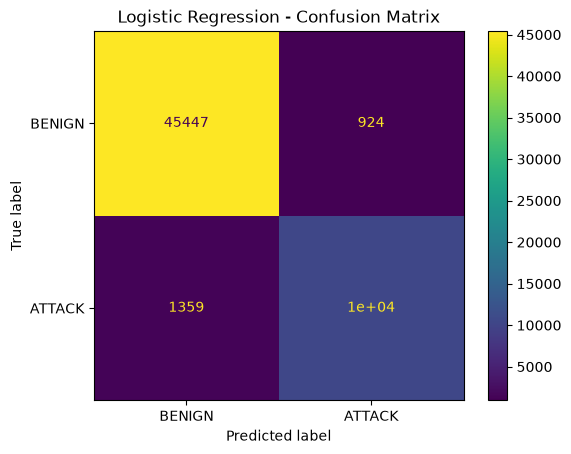

In [81]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 8.9 Baseline Model Summary

### Logistic Regression

| Metric | Score |
|---|---:|
| Accuracy | 96.08% |
| Precision | 91.88% |
| Recall | 88.50% |
| F1 Score | 90.16% |

### Confusion Matrix

- True Negatives: 45,447
- False Positives: 924
- False Negatives: 1,359
- True Positives: 10,460

### Observation

The Logistic Regression model provides a strong baseline with
96.08% accuracy and 90.16% F1 score. However, the attack recall
of 88.50% means that 1,359 attacks were incorrectly classified
as BENIGN. Since missed attacks are particularly important in a
cybersecurity system, we will investigate whether a more powerful
model can improve attack detection.